# Ejercicio 3 - Criterio de Nyquist y filtro coseno realzado

Un sistema transmite simbolos binarios a una tasa:

$$R_s = 2.5 \times 10^6 \; \text{simbolos/s}$$

Se desea evitar ISI utilizando el criterio de Nyquist.

La consigna pide:

1. Determinar el ancho de banda minimo requerido para transmision en banda base.
2. Determinar el ancho de banda si se utilizan filtros raiz coseno realzado tanto en el transmisor como en el receptor, con factor de roll-off `beta = 0.25` y `beta = 0.5`.

## Idea teorica

El criterio de Nyquist busca que la ISI sea cero en los instantes de muestreo. Para una transmision en banda base con simbolos separados cada:

$$T_s = \frac{1}{R_s}$$

el caso ideal de minimo ancho de banda se obtiene con un pulso sinc en el tiempo. Ese pulso tiene un espectro rectangular en frecuencia, limitado entre:

$$-\frac{R_s}{2} \leq f \leq \frac{R_s}{2}$$

Por eso, el ancho de banda minimo de banda base, medido desde `0` hasta la frecuencia positiva maxima, es:

$$B_{min}=\frac{R_s}{2}$$

Si se habla de ancho total doble lado, es decir desde `-B` hasta `+B`, entonces el ancho total es:

$$2B_{min}=R_s$$

Esta diferencia de lenguaje es importante: en comunicaciones muchas veces se informa el ancho de banda positivo `B`, pero en las graficas de banda base se ve el espectro completo entre `-B` y `+B`.

## Coseno realzado y raiz coseno realzado

El pulso sinc ideal cumple Nyquist con el minimo ancho de banda, pero tiene un problema practico: se extiende infinitamente en el tiempo. Por eso en sistemas reales se usan pulsos como el **coseno realzado** (`raised cosine`) o la **raiz de coseno realzado** (`root raised cosine`).

El factor de roll-off `beta` controla cuanto ancho de banda extra se usa respecto del minimo ideal:

$$0 \leq \beta \leq 1$$

Para un filtro coseno realzado, el ancho de banda positivo es:

$$B = \frac{(1+\beta)R_s}{2}$$

Si se usan filtros **raiz coseno realzado** en transmisor y receptor, cada uno tiene una respuesta que es la raiz del coseno realzado. Al pasar por ambos filtros, la respuesta total es:

$$H_{total}(f)=H_{RRC}(f)H_{RRC}(f)=H_{RC}(f)$$

Entonces el ancho de banda ocupado es el mismo que el del coseno realzado total:

$$B = \frac{(1+\beta)R_s}{2}$$

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Tasa de simbolos dada por la consigna.
Rs = 2.5e6  # simbolos/s
Ts = 1 / Rs

print(f"Rs = {Rs:.2e} simbolos/s")
print(f"Ts = {Ts:.2e} s")

Rs = 2.50e+06 simbolos/s
Ts = 4.00e-07 s


# Punto 1 - Ancho de banda minimo en banda base

Para evitar ISI con el criterio de Nyquist en el caso ideal de minimo ancho de banda:

$$B_{min}=\frac{R_s}{2}$$

Como `Rs = 2.5e6 simbolos/s`:

$$B_{min}=\frac{2.5\times 10^6}{2}=1.25\times 10^6 \; \text{Hz}$$

Entonces:

$$B_{min}=1.25 \; \text{MHz}$$

In [6]:
B_min = Rs / 2
BW_total_min = 2 * B_min

print(f"Ancho de banda minimo positivo Bmin = {B_min/1e6:.3f} MHz")
print(f"Ancho total doble lado [-B, +B] = {BW_total_min/1e6:.3f} MHz")

Ancho de banda minimo positivo Bmin = 1.250 MHz
Ancho total doble lado [-B, +B] = 2.500 MHz


## Punto 2 - Ancho de banda con raiz coseno realzado

Con factor de roll-off `beta`, el ancho de banda positivo es:

$$B=\frac{(1+\beta)R_s}{2}$$

Para `beta = 0.25`:

$$B=\frac{(1+0.25)2.5\times10^6}{2}=1.5625\;\text{MHz}$$

Para `beta = 0.5`:

$$B=\frac{(1+0.5)2.5\times10^6}{2}=1.875\;\text{MHz}$$

In [7]:
betas = np.array([0.25, 0.5])
B_rrc = (1 + betas) * Rs / 2
BW_total_rrc = 2 * B_rrc

print("Resultados con filtros raiz coseno realzado en Tx y Rx")
print("--------------------------------------------------------")
for beta, B, BW_total in zip(betas, B_rrc, BW_total_rrc):
    print(f"beta = {beta:.2f} | B positivo = {B/1e6:.4f} MHz | ancho total [-B,+B] = {BW_total/1e6:.4f} MHz")

Resultados con filtros raiz coseno realzado en Tx y Rx
--------------------------------------------------------
beta = 0.25 | B positivo = 1.5625 MHz | ancho total [-B,+B] = 3.1250 MHz
beta = 0.50 | B positivo = 1.8750 MHz | ancho total [-B,+B] = 3.7500 MHz


## Grafica del espectro

En la siguiente grafica se compara el caso ideal de Nyquist, equivalente a `beta = 0`, con los casos `beta = 0.25` y `beta = 0.5`.

La parte plana del espectro se reduce a medida que aumenta `beta`, pero aparece una zona de transicion mas suave. Esa zona de transicion ocupa ancho de banda extra. Por eso, a mayor `beta`, mayor ancho de banda requerido, aunque el pulso suele ser mas realizable en la practica que la sinc ideal.

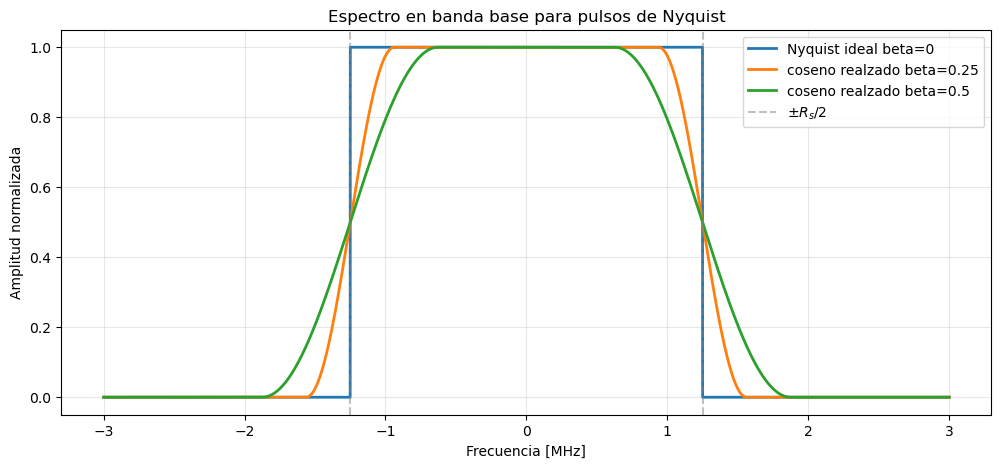

In [8]:
def raised_cosine_spectrum(f, Rs, beta):
    """Espectro ideal de coseno realzado normalizado en amplitud.

    Devuelve una forma proporcional a H_RC(f). Para este ejercicio importa la forma
    y el ancho de banda, no la constante de escala absoluta.
    """
    f_abs = np.abs(f)
    H = np.zeros_like(f_abs, dtype=float)

    if beta == 0:
        H[f_abs <= Rs/2] = 1.0
        return H

    f1 = (1 - beta) * Rs / 2
    f2 = (1 + beta) * Rs / 2

    H[f_abs <= f1] = 1.0
    transicion = (f_abs > f1) & (f_abs <= f2)
    H[transicion] = 0.5 * (1 + np.cos(np.pi / (beta * Rs) * (f_abs[transicion] - f1)))
    return H

f = np.linspace(-3e6, 3e6, 6000)

plt.figure(figsize=(12, 5))
for beta in [0, 0.25, 0.5]:
    H = raised_cosine_spectrum(f, Rs, beta)
    etiqueta = "Nyquist ideal beta=0" if beta == 0 else f"coseno realzado beta={beta}"
    plt.plot(f/1e6, H, linewidth=2, label=etiqueta)

plt.axvline(-B_min/1e6, color="gray", linestyle="--", alpha=0.5)
plt.axvline(B_min/1e6, color="gray", linestyle="--", alpha=0.5, label=r"$\pm R_s/2$")

plt.title("Espectro en banda base para pulsos de Nyquist")
plt.xlabel("Frecuencia [MHz]")
plt.ylabel("Amplitud normalizada")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Conclusion

El ancho de banda minimo requerido para transmision en banda base sin ISI ideal es `1.25 MHz`, que corresponde a `Rs/2`. En una grafica de banda base centrada en cero, esto se observa como un espectro que ocupa desde `-1.25 MHz` hasta `+1.25 MHz`, es decir un ancho total doble lado de `2.5 MHz`.

Al utilizar filtros raiz coseno realzado en el transmisor y receptor, la respuesta combinada cumple el criterio de Nyquist, pero ocupa un ancho de banda mayor que el caso ideal. Para `beta = 0.25`, el ancho positivo requerido es `1.5625 MHz`; para `beta = 0.5`, es `1.875 MHz`.

El factor `beta` representa el exceso de ancho de banda respecto del minimo de Nyquist. Cuanto mayor es `beta`, mas ancho de banda se ocupa, pero mas suave es la transicion espectral y mas realizable resulta el filtrado en un sistema practico.

## Aclaracion final: sinc, ancho minimo y exceso de banda

Si en tiempo se utiliza el pulso ideal:

$$h(t)=\operatorname{sinc}\left(\frac{t}{T}\right)$$

su transformada de Fourier es un rectangulo en frecuencia:

$$H(f)=T\,\operatorname{rect}(fT)$$

Ese rectangulo queda limitado entre:

$$-\frac{1}{2T} \leq f \leq \frac{1}{2T}$$

Como la tasa de simbolos es:

$$R_s=\frac{1}{T}$$

el ancho de banda minimo positivo es:

$$B_{min}=\frac{1}{2T}=\frac{R_s}{2}$$

Para este ejercicio:

$$B_{min}=\frac{2.5\times10^6}{2}=1.25\times10^6\;\text{Hz}=1.25\;\text{MHz}$$

Cuando se usa coseno realzado o raiz coseno realzado, aparece un exceso de ancho de banda controlado por `beta`. Ese exceso puede pensarse como:

$$\Delta B = B - B_{min}$$

y como:

$$B=\frac{(1+\beta)R_s}{2}$$

entonces:

$$\Delta B=\frac{\beta R_s}{2}$$

Por lo tanto, la sinc ideal da el ancho de banda minimo, mientras que el coseno realzado agrega una banda de transicion `Delta B` para hacer el filtro mas realizable en la practica.

In [9]:
# Calculo del exceso de ancho de banda Delta B para cada beta.
delta_B = B_rrc - B_min

print(f"Bmin = {B_min/1e6:.4f} MHz")
for beta, B, dB in zip(betas, B_rrc, delta_B):
    print(f"beta = {beta:.2f} | B = {B/1e6:.4f} MHz | Delta B = {dB/1e6:.4f} MHz")

Bmin = 1.2500 MHz
beta = 0.25 | B = 1.5625 MHz | Delta B = 0.3125 MHz
beta = 0.50 | B = 1.8750 MHz | Delta B = 0.6250 MHz


## Aclaracion: raiz coseno realzado en transmisor y receptor

La consigna no pide usar un unico filtro coseno realzado, sino filtros **raiz coseno realzado** tanto en el transmisor como en el receptor. Esto se hace porque se reparte el filtrado entre ambos extremos del sistema.

Un filtro raiz coseno realzado individualmente no es la respuesta total de Nyquist. Se llama raiz porque su respuesta en frecuencia es la raiz cuadrada de la respuesta del coseno realzado:

$$H_{RRC}(f)=\sqrt{H_{RC}(f)}$$

Si en el transmisor se coloca un filtro raiz coseno realzado y en el receptor se coloca otro igual, la respuesta total en frecuencia es el producto de las dos respuestas:

$$H_{total}(f)=H_{Tx}(f)H_{Rx}(f)$$

$$H_{total}(f)=H_{RRC}(f)H_{RRC}(f)$$

$$H_{total}(f)=\sqrt{H_{RC}(f)}\sqrt{H_{RC}(f)}=H_{RC}(f)$$

En el dominio del tiempo, esta multiplicacion en frecuencia equivale a una convolucion de las respuestas impulsivas:

$$h_{total}(t)=h_{Tx}(t)*h_{Rx}(t)$$

Por eso, aunque cada filtro raiz coseno realzado por separado no representa la respuesta completa de Nyquist, el conjunto transmisor + receptor produce una respuesta coseno realzado total. Como el coseno realzado cumple el criterio de Nyquist, el sistema completo elimina ISI en los instantes de muestreo.

Dicho de forma corta: el transmisor aplica una raiz, el receptor aplica la otra raiz, y juntos forman el filtro coseno realzado completo.

## Interpretacion como fraccion de la tasa de simbolos

El ancho de banda positivo del coseno realzado puede verse como el ancho minimo mas un exceso:

$$B=B_{min}+\Delta B$$

donde:

$$B_{min}=\frac{1}{2T}=\frac{R_s}{2}$$

y:

$$\Delta B=\beta\frac{1}{2T}=\beta\frac{R_s}{2}$$

Entonces:

$$B=\frac{R_s}{2}+\beta\frac{R_s}{2}=\frac{(1+\beta)R_s}{2}$$

Esto permite expresar el ancho de banda como fraccion de la tasa de simbolos:

$$\frac{B}{R_s}=\frac{1+\beta}{2}$$

Para `beta = 0.25`:

$$\frac{B}{R_s}=\frac{1+0.25}{2}=0.625$$

$$B=0.625R_s=0.625(2.5\;\text{MHz})=1.5625\;\text{MHz}$$

Para `beta = 0.5`:

$$\frac{B}{R_s}=\frac{1+0.5}{2}=0.75$$

$$B=0.75R_s=0.75(2.5\;\text{MHz})=1.875\;\text{MHz}$$

Por eso, para `beta = 0.5`, el ancho de banda positivo es tres cuartos de la tasa de simbolos. Para `beta = 0.25`, el ancho de banda positivo es `0.625` veces la tasa de simbolos.

Aclaracion importante: estos valores corresponden al ancho positivo `B`, desde `0` hasta la frecuencia maxima positiva. Si se mira el espectro completo en banda base, aparece entre `-B` y `+B`; por lo tanto, el ancho total doble lado es:

$$2B=(1+\beta)R_s$$

Entonces, para `beta = 0.5`, el ancho total doble lado seria `1.5R_s`, no `0.75R_s`.